In [456]:
import pandas as pd

In [457]:
df = pd.read_csv('customer.csv')

In [458]:
df.shape

(50000, 8)

In [459]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,565612,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-09-05 15:17:00,1.95,12616.0,France
1,539735,18098c,PORCELAIN BUTTERFLY OIL BURNER,2,2010-12-21 15:17:00,5.06,NaN,United Kingdom
2,559557,22398,MAGNETS PACK OF 4 SWALLOWS,12,2011-07-11 10:33:00,0.39,17444.0,Canada
3,551747,85039C,S/4 BLACK MINI ROSE CANDLE IN BOWL,96,2011-05-04 11:00:00,0.42,14298.0,United Kingdom
4,550636,85202,HANGING WOOD AND FELT HEART,2,2011-04-19 15:37:00,0.79,NaN,United Kingdom


In [460]:
df = df.drop_duplicates()

In [461]:
df.isnull().sum()

InvoiceNo          0
StockCode          0
Description      141
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     12394
Country            0
dtype: int64

In [462]:
df.nunique()

InvoiceNo      14441
StockCode       3324
Description     3371
Quantity         248
InvoiceDate    13657
UnitPrice        433
CustomerID      3753
Country           37
dtype: int64

In [463]:
df = df.dropna(subset=['CustomerID'])

In [464]:
df.shape

(37560, 8)

In [465]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37560 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37560 non-null  object 
 1   StockCode    37560 non-null  object 
 2   Description  37560 non-null  object 
 3   Quantity     37560 non-null  int64  
 4   InvoiceDate  37560 non-null  object 
 5   UnitPrice    37560 non-null  float64
 6   CustomerID   37560 non-null  float64
 7   Country      37560 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.6+ MB


In [466]:
df['CustomerID'] =df['CustomerID'].astype(int)

In [467]:
df = df[df['UnitPrice'] > 0]
df = df[df['Quantity'] > 0]

array([[<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'UnitPrice'}>],
       [<Axes: title={'center': 'CustomerID'}>, <Axes: >]], dtype=object)

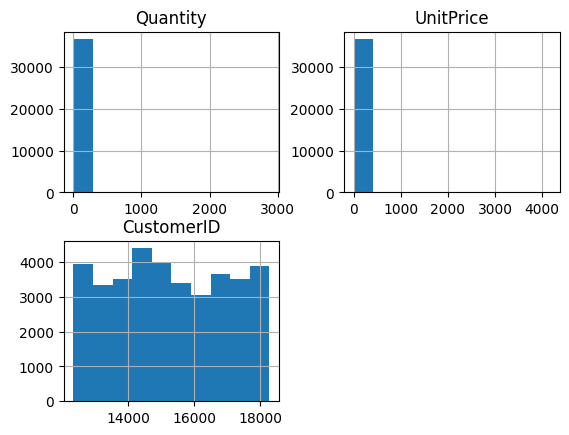

In [468]:
df.hist()

In [469]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,565612,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-09-05 15:17:00,1.95,12616,France
2,559557,22398,MAGNETS PACK OF 4 SWALLOWS,12,2011-07-11 10:33:00,0.39,17444,Canada
3,551747,85039C,S/4 BLACK MINI ROSE CANDLE IN BOWL,96,2011-05-04 11:00:00,0.42,14298,United Kingdom
5,580152,22708,WRAP DOLLY GIRL,25,2011-12-02 10:22:00,0.42,12364,Belgium
6,567186,21621,VINTAGE UNION JACK BUNTING,3,2011-09-18 16:04:00,8.50,17073,United Kingdom


In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36726 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    36726 non-null  object 
 1   StockCode    36726 non-null  object 
 2   Description  36726 non-null  object 
 3   Quantity     36726 non-null  int64  
 4   InvoiceDate  36726 non-null  object 
 5   UnitPrice    36726 non-null  float64
 6   CustomerID   36726 non-null  int64  
 7   Country      36726 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 2.5+ MB


In [471]:
df['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
False    36726
Name: count, dtype: int64

In [472]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [473]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,565612,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-09-05 15:17:00,1.95,12616,France,15.60
2,559557,22398,MAGNETS PACK OF 4 SWALLOWS,12,2011-07-11 10:33:00,0.39,17444,Canada,4.68
3,551747,85039C,S/4 BLACK MINI ROSE CANDLE IN BOWL,96,2011-05-04 11:00:00,0.42,14298,United Kingdom,40.32
5,580152,22708,WRAP DOLLY GIRL,25,2011-12-02 10:22:00,0.42,12364,Belgium,10.50
6,567186,21621,VINTAGE UNION JACK BUNTING,3,2011-09-18 16:04:00,8.50,17073,United Kingdom,25.50


In [474]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [475]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days


recency = recency[['CustomerID','Recency']]

In [476]:
recency

,CustomerID,Recency
0,12347,40
1,12348,249
2,12349,19
3,12350,310
4,12352,36
...,...,...
3724,18277,58
3725,18280,278
3726,18281,181
3727,18283,4


In [477]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = ['CustomerID','Frequency']
frequency

,CustomerID,Frequency
0,12347,6
1,12348,3
2,12349,1
3,12350,1
4,12352,3
...,...,...
3724,18277,1
3725,18280,1
3726,18281,1
3727,18283,15


In [478]:
monetary = (
    df.groupby('CustomerID')['TotalAmount']
      .sum()
      .reset_index()
)

monetary.columns = ['CustomerID', 'Monetary']

In [479]:
rfm = recency.merge(
    frequency,
    on='CustomerID'
).merge(
    monetary,
    on='CustomerID'
)

In [480]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12347,40,6,412.26
1,12348,249,3,161.28
2,12349,19,1,178.68
3,12350,310,1,45.60
4,12352,36,3,158.43


In [481]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,3729.000000,3729.000000,3729.000000
mean,97.618128,3.370877,218.669252
std,101.433182,5.710047,924.482274
min,1.000000,1.000000,0.780000
25%,21.000000,1.000000,32.250000
50%,57.000000,2.000000,75.150000
75%,152.000000,4.000000,175.980000
max,374.000000,155.000000,25502.190000


In [482]:
import numpy as np
rfm_log = np.log1p(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [483]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
X_scale = Scaler.fit_transform(rfm_log)

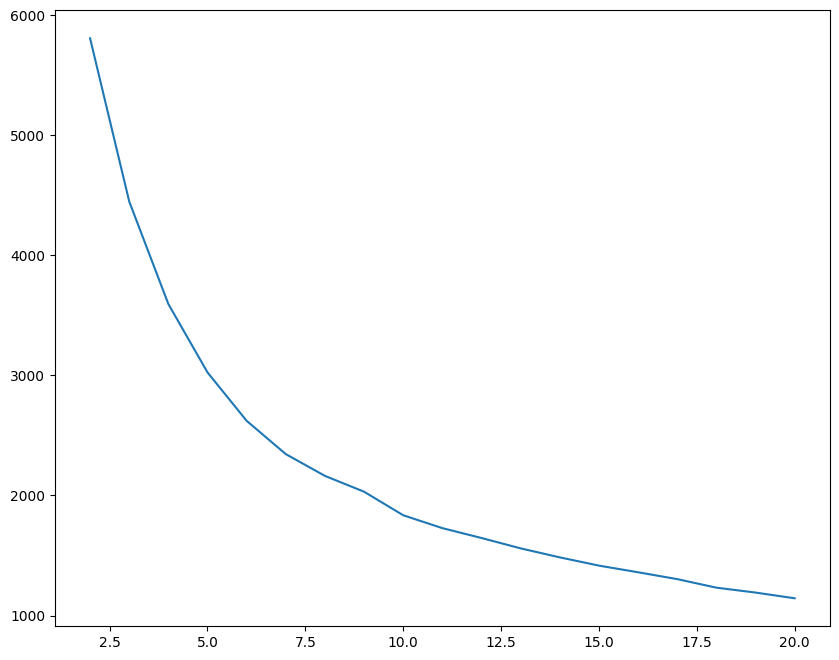

In [484]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

wcss = []
s_score = []
for k in range(2,21):
    model = KMeans(n_clusters=k)
    label = model.fit_predict(X_scale)
    wcss.append(model.inertia_)
    s_score.append(silhouette_score(X_scale, label))
    

plt.figure(figsize=(10,8))
plt.plot(range(2,21), wcss)
plt.show()

    


In [485]:
from kneed import KneeLocator

elbow = KneeLocator(range(2,21), wcss, direction='decreasing', curve='convex')
print(elbow.elbow)

7


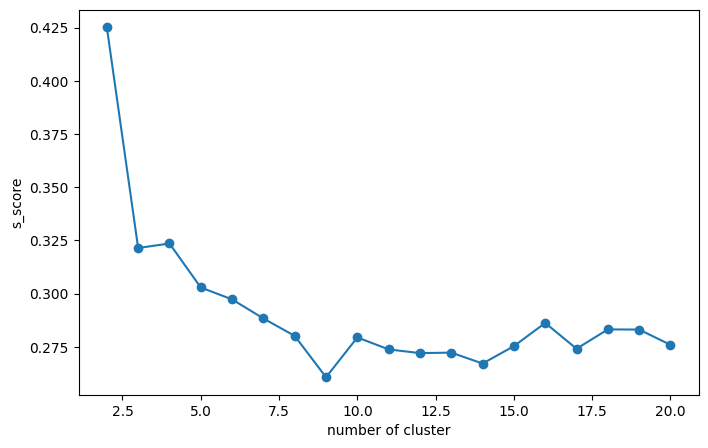

In [486]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 21), s_score, marker='o')
plt.xlabel('number of cluster')
plt.ylabel('s_score')
plt.show()

In [491]:
kmean = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmean.fit_predict(X_scale)

In [492]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     649
1    1595
2    1485
Name: count, dtype: int64

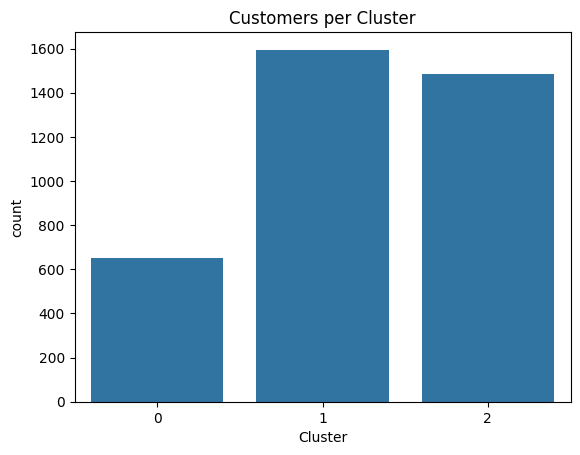

In [493]:
sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Customers per Cluster')
plt.show()

In [494]:
cluster_profile= (rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,17.92,10.13,838.50
1,170.89,1.19,39.86
2,53.75,2.76,139.83


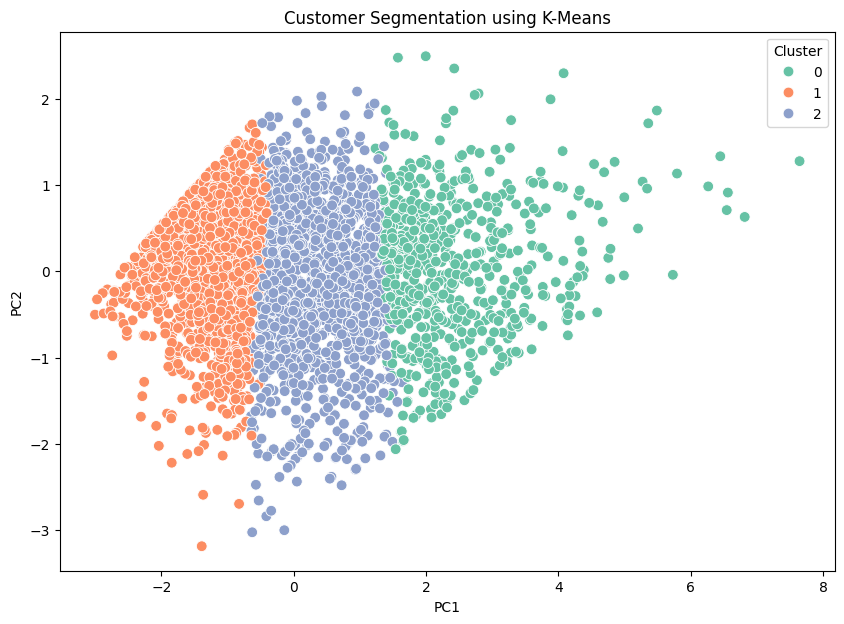

In [497]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scale)

rfm['PC1'] = X_pca[:, 0]
rfm['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segmentation using K-Means')
plt.show()